In [8]:
!pip install spacy



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
!python -m spacy download en_core_web_md


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 10.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Imports & Config
# ─────────────────────────────────────────────────────────────────────────────

import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

DATA_PATHS: Dict[str, Path] = {
    'gaia'     : Path('../datasets/processed/gaia.parquet'),
    'aime'     : Path('../datasets/processed/aime.parquet'),
    'mmlu_pro' : Path('../datasets/processed/mmlu_pro.parquet'),
    'musique'  : Path('../datasets/processed/musique.parquet'),
    'swe_bench' : Path('../datasets/processed/swe_bench.parquet'),
}

OUTPUT_DIR = Path('data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')
print(f'   pandas  {pd.__version__}')
for name, path in DATA_PATHS.items():
    print(f'   {name:<10} → {path}')

✅ Imports OK
   pandas  3.0.1
   gaia       → ../datasets/processed/gaia.parquet
   aime       → ../datasets/processed/aime.parquet
   mmlu_pro   → ../datasets/processed/mmlu_pro.parquet
   musique    → ../datasets/processed/musique.parquet
   swe_bench  → ../datasets/processed/swe_bench.parquet


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Load & Preview All Datasets
# ─────────────────────────────────────────────────────────────────────────────

datasets: Dict[str, pd.DataFrame] = {}

for name, path in DATA_PATHS.items():
    df = pd.read_parquet(path)
    datasets[name] = df
    print(f"\n{'─' * 60}")
    print(f"📂 Dataset : {name.upper()}")
    print(f"   Path    : {path}")
    print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   Columns : {list(df.columns)}")
    print(f"   Nulls   : {df.isnull().sum().sum():,} total missing values")
    # print(f"\n{df.head()}\n")

print(f"\n✅ Loaded {len(datasets)} datasets successfully")


────────────────────────────────────────────────────────────
📂 Dataset : GAIA
   Path    : ../datasets/processed/gaia.parquet
   Shape   : 165 rows × 7 cols
   Columns : ['id', 'query', 'answer', 'level', 'annotator_steps', 'annotator_tools', 'file_name']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : AIME
   Path    : ../datasets/processed/aime.parquet
   Shape   : 30 rows × 5 cols
   Columns : ['id', 'query', 'answer', 'year', 'solution']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MMLU_PRO
   Path    : ../datasets/processed/mmlu_pro.parquet
   Shape   : 12,032 rows × 9 cols
   Columns : ['id', 'query', 'answer', 'answer_index', 'options', 'category', 'cot_content', 'src', 'cot_length']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MUSIQUE
   Path    : ../datasets/processed/musique.parquet
   

In [23]:
datasets['aime']

,id,query,answer,year,solution
0,60,Every morning Aya goes for a $9$-kilometer-lon...,204,2024,$\frac{9}{s} + t = 4$ in hours and $\frac{9}{s...
1,61,Let $ABC$ be a triangle inscribed in circle $\...,113,2024,From the tangency condition we have $\let\angl...
2,62,Each vertex of a regular octagon is independen...,371,2024,Notice that the question's condition mandates ...
3,63,Define $f(x)=|| x|-\tfrac{1}{2}|$ and $g(x)=||...,385,2024,"If we graph $4g(f(x))$, we see it forms a sawt..."
4,64,Let $p$ be the least prime number for which th...,110,2024,"If \(p=2\), then \(4\mid n^4+1\) for some inte..."
5,65,Let $ABCD$ be a tetrahedron such that $AB=CD= ...,104,2024,"Notice that \(41=4^2+5^2\), \(89=5^2+8^2\), an..."
6,66,Let $\mathcal{B}$ be the set of rectangular bo...,721,2024,"Observe that the ""worst"" possible box is one o..."
7,67,"There exist real numbers $x$ and $y$, both gre...",025,2024,"By properties of logarithms, we can simplify t..."
8,68,Alice and Bob play the following game. A stack...,809,2024,Let's first try some experimentation. Alice ob...
9,69,Jen enters a lottery by picking $4$ distinct n...,116,2024,This is a conditional probability problem. Bay...


In [24]:
sample= datasets['gaia']["query"][0]

In [25]:
sample

'A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?'

In [ ]:

# L1 Surface features

import spacy  

_NLP = spacy.load("en_core_web_md", disable=["parser", "tagger"])
class SurfaceFeatures:
    def __init__(self, text: str):
        self.text = text

    def _tokencount(self, q: str) -> int:
        return len(q.split())

    def _ner_features(self, q: str) -> dict:
        doc          = _NLP(q)
        total_tokens = max(len(doc), 1)
        entity_count = len(doc.ents)
        type_counts  = {}
        for ent in doc.ents:
            type_counts[ent.label_] = type_counts.get(ent.label_, 0) + 1

        return {
            # "ner_count"   : entity_count,
            "ner_density" : round(entity_count / total_tokens, 4),
        }
    def _mattr(self, q: str, window: int = 25) -> float:
        """
        Moving Average Type-Token Ratio (MATTR).
        Slides a fixed window across tokens, computes TTR at each position,
        returns the mean — length-independent unlike raw TTR.
        Returns raw TTR if text is shorter than the window.
        """
        tokens = q.lower().split()
        n      = len(tokens)

        if n == 0:
            return 0.0
        if n <= window:                              # too short to slide — fall back to TTR
            return round(len(set(tokens)) / n, 4)

        ttr_scores = [
            len(set(tokens[i : i + window])) / window
            for i in range(n - window + 1)          # slide one token at a time
        ]
        return round(sum(ttr_scores) / len(ttr_scores), 4)

    def surface_features(self) -> dict:
        base = {
            "token_count":     self._tokencount(self.text),
            "mattr":           self._mattr(self.text, window=25)
        }
        base.update(self._ner_features(self.text))
        return base



In [73]:
def compute_surface_features(df: pd.DataFrame, text_col: str) -> pd.DataFrame:
    """
    For each incoming query row, instantiates SurfaceFeatures
    and computes all 6 features independently per query.
    """
    records = []
    for query in df[text_col].astype(str):         # ← iterate each query
        sf = SurfaceFeatures(query)                # ← new instance per query
        records.append(sf.surface_features())      # ← compute on that query

    feature_df = pd.DataFrame(records, index=df.index)
    return pd.concat([df, feature_df], axis=1)


In [74]:
TEXT_COL_MAP: Dict[str, str] = {
    'gaia'      : 'query',
    'aime'      : 'query',
    'mmlu_pro'  : 'query',
    'musique'   : 'query',
    'swe_bench' : 'query',
}

In [58]:
FEATURE_COLS = [
    "token_count", "ner_density", "mattr"
]

In [59]:
enriched: Dict[str, pd.DataFrame] = {}
summary_rows = []

for name, df in datasets.items():
    text_col = TEXT_COL_MAP.get(name, 'query')

    if text_col not in df.columns:
        print(f"⚠️  '{name}' has no column '{text_col}'. Available: {list(df.columns)}")
        continue

    enriched[name] = compute_surface_features(df, text_col)

    feat_df = enriched[name][FEATURE_COLS]
    row = {"dataset": name, "rows": len(df)}
    for col in FEATURE_COLS:
        row[f"{col}_mean"] = round(feat_df[col].mean(), 2)
        row[f"{col}_max"]  = feat_df[col].max()
    summary_rows.append(row)
    tc = feat_df["token_count"]
    print(f"\n{'─' * 60}")
    print(f"📊 {name.upper()}  ({len(df):,} queries)")
    print(f"   token_count  →  mean={tc.mean():.1f}  median={tc.median():.1f}"
          f"  min={tc.min()}  max={tc.max()}  p95={tc.quantile(0.95):.0f}")
    print(feat_df.describe().round(2).to_string())




────────────────────────────────────────────────────────────
📊 GAIA  (165 queries)
   token_count  →  mean=52.7  median=39.0  min=9  max=380  p95=118
       token_count  ner_density   mattr
count       165.00       165.00  165.00
mean         52.68         0.08    0.87
std          44.80         0.05    0.07
min           9.00         0.00    0.56
25%          26.00         0.05    0.83
50%          39.00         0.08    0.88
75%          62.00         0.11    0.91
max         380.00         0.22    1.00

────────────────────────────────────────────────────────────
📊 AIME  (30 queries)
   token_count  →  mean=54.0  median=55.0  min=15  max=123  p95=86
       token_count  ner_density  mattr
count        30.00        30.00  30.00
mean         54.00         0.08   0.86
std          25.13         0.03   0.08
min          15.00         0.02   0.65
25%          36.50         0.06   0.81
50%          55.00         0.08   0.86
75%          76.50         0.10   0.90
max         123.00         

### Dataset Overview - GAIA

1. Total queries analyzed: 165
2. These are individual prompts/questions from GAIA.
### Token Count (Length of Queries)
1. Average (mean): ~53 tokens → typical query length
2. Median: 39 tokens → half the queries are shorter than this
3. Minimum: 9 tokens → very short queries exist
4. Maximum: 380 tokens → some very long/complex queries
5. 95th percentile (p95): 118 tokens → most queries are under this length
   

In [60]:
summary_df = pd.DataFrame(summary_rows).set_index("dataset")
print(f"\n{'═' * 60}")
print("📋 CROSS-DATASET SUMMARY (means per query)")
print('═' * 60)
mean_cols = [c for c in summary_df.columns if c.endswith("_mean")]
print(summary_df[mean_cols].rename(columns=lambda c: c.replace("_mean", "")).to_string())



════════════════════════════════════════════════════════════
📋 CROSS-DATASET SUMMARY (means per query)
════════════════════════════════════════════════════════════
           token_count  ner_density  mattr
dataset                                   
gaia             52.68         0.08   0.87
aime             54.00         0.08   0.86
mmlu_pro         45.25         0.06   0.89
musique          18.11         0.09   0.88
swe_bench       189.31         0.05   0.87


In [61]:
for name, df in enriched.items():
    out_path = OUTPUT_DIR / f"{name}_with_features.parquet"
    df.to_parquet(out_path, index=False)
    print(f"\n💾 Saved → {out_path}")

print("\n✅ Surface features computed at query level for all datasets")


💾 Saved → data/processed/gaia_with_features.parquet

💾 Saved → data/processed/aime_with_features.parquet

💾 Saved → data/processed/mmlu_pro_with_features.parquet

💾 Saved → data/processed/musique_with_features.parquet

💾 Saved → data/processed/swe_bench_with_features.parquet

✅ Surface features computed at query level for all datasets


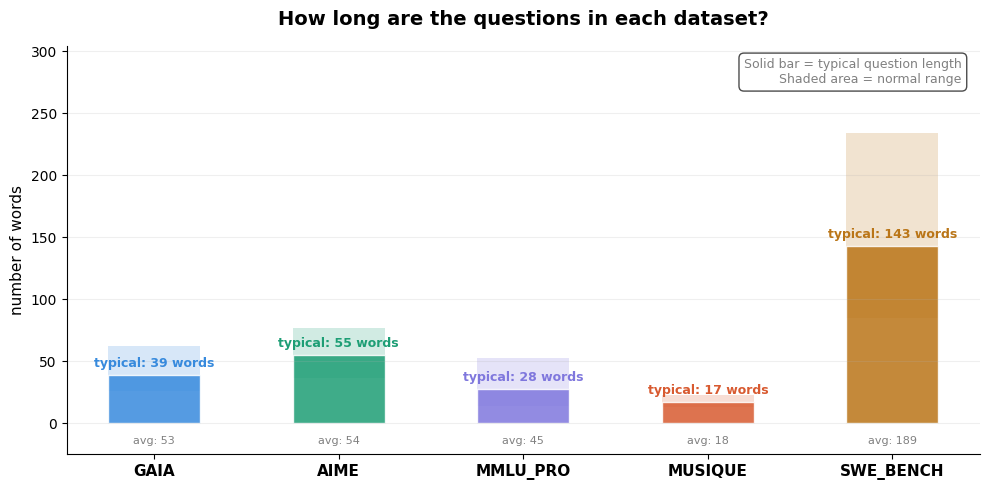

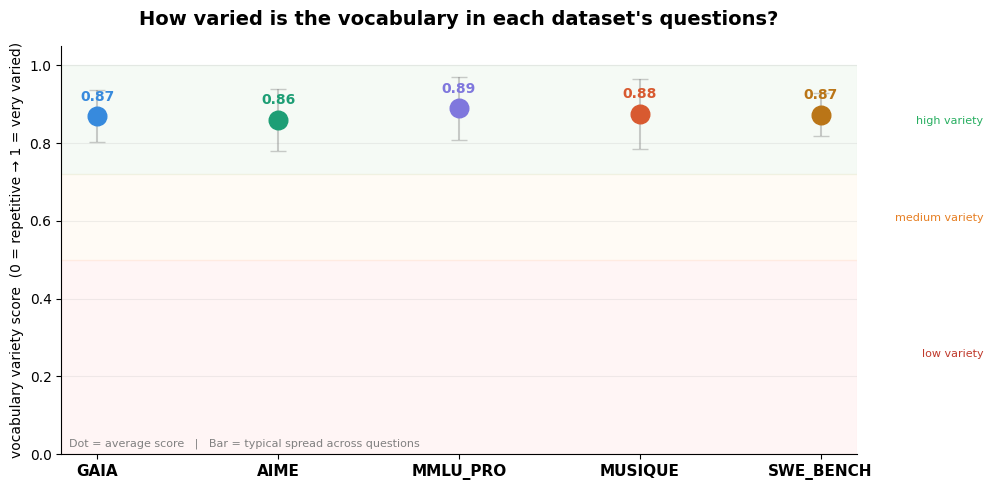

In [65]:
#import matplotlib.pyplot as plt
import numpy as np

dataset_names = list(enriched.keys())
n             = len(dataset_names)
COLORS        = ['#378ADD', '#1D9E75', '#7F77DD', '#D85A30', '#BA7517']

def get(name, col):
    return enriched[name][col] if col in enriched[name].columns else pd.Series([0])

# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — How long are the questions? (simple bar with range band)
# ═════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

means   = [get(name, "token_count").mean()            for name in dataset_names]
medians = [get(name, "token_count").median()           for name in dataset_names]
p25     = [get(name, "token_count").quantile(0.25)     for name in dataset_names]
p75     = [get(name, "token_count").quantile(0.75)     for name in dataset_names]

x = np.arange(n)

# shaded band = typical range (25th–75th percentile)
for i in range(n):
    ax.bar(i, p75[i] - p25[i], bottom=p25[i],
           color=COLORS[i], alpha=0.2, width=0.5)

# median bar
bars = ax.bar(x, medians, color=COLORS, alpha=0.85, width=0.5, edgecolor='white')

# annotate each bar with plain English
for i, (name, med, mean) in enumerate(zip(dataset_names, medians, means)):
    ax.text(i, med + 4, f"typical: {med:.0f} words",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS[i])
    ax.text(i, -18, f"avg: {mean:.0f}",
            ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in dataset_names], fontsize=11, fontweight='bold')
ax.set_ylabel("number of words", fontsize=11)
ax.set_title("How long are the questions in each dataset?",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(-25, max(p75) * 1.3)

# plain English legend
ax.text(0.98, 0.97,
        "Solid bar = typical question length\nShaded area = normal range",
        transform=ax.transAxes, fontsize=9, color='gray',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7))

ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "simple_fig1_question_length.png", dpi=150, bbox_inches='tight')
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — How varied is the vocabulary? (MATTR as simple dot + range)
# ═════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

mattr_means = [get(name, "mattr").mean()   for name in dataset_names]
mattr_stds  = [get(name, "mattr").std()    for name in dataset_names]

# horizontal reference bands
ax.axhspan(0.0,  0.5,  alpha=0.04, color='red',   label='low variety')
ax.axhspan(0.5,  0.72, alpha=0.04, color='orange', label='medium variety')
ax.axhspan(0.72, 1.0,  alpha=0.04, color='green',  label='high variety')

ax.text(n - 0.1, 0.25,  'low variety',    fontsize=8, color='#c0392b', ha='right')
ax.text(n - 0.1, 0.60,  'medium variety', fontsize=8, color='#e67e22', ha='right')
ax.text(n - 0.1, 0.85,  'high variety',   fontsize=8, color='#27ae60', ha='right')

# error bars (±1 std)
ax.errorbar(range(n), mattr_means, yerr=mattr_stds,
            fmt='none', color='gray', alpha=0.4, capsize=6, linewidth=1.5)

# dots
for i, (mean, color) in enumerate(zip(mattr_means, COLORS)):
    ax.scatter(i, mean, s=180, color=color, zorder=5)
    ax.text(i, mean + 0.04, f"{mean:.2f}",
            ha='center', fontsize=10, fontweight='bold', color=color)

ax.set_xticks(range(n))
ax.set_xticklabels([d.upper() for d in dataset_names], fontsize=11, fontweight='bold')
ax.set_ylabel("vocabulary variety score  (0 = repetitive → 1 = very varied)", fontsize=10)
ax.set_title("How varied is the vocabulary in each dataset's questions?",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

ax.text(0.01, 0.02,
        "Dot = average score   |   Bar = typical spread across questions",
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "simple_fig2_vocabulary_variety.png", dpi=150, bbox_inches='tight')
plt.show()


In [75]:
# Reasogning demand


import re
from typing import Optional

# ── compile once at module level — never inside a method ─────────────────────

_BLOOM_VERBS: dict[int, list[str]] = {
    1: [
        "define","list","recall","name","identify","recognize","state","label",
        "match","select","locate","arrange","duplicate","memorize","repeat",
        "reproduce","copy","quote","order","record","relate","underline",
        "who is","when was","where is","what year","what is the capital",
    ],
    2: [
        "explain","describe","interpret","paraphrase","restate","translate",
        "clarify","elaborate","simplify","convert","classify","categorize",
        "sort","group","infer","predict","conclude from","anticipate",
        "extrapolate","summarize","abstract","generalize","outline",
        "illustrate","give an example","represent","compare","report",
        "review","discuss","indicate","rewrite","what is the difference",
    ],
    3: [
        "apply","use","implement","execute","carry out","perform","administer",
        "operate","employ","utilize","solve","compute","calculate","estimate",
        "determine","find","derive the value","work out","demonstrate",
        "show how to","illustrate how","construct","build","produce","make",
        "prepare","complete","modify","develop a solution","simulate","run",
        "test","sketch","map","write a function","code","script",
    ],
    4: [
        "analyze","analyse","differentiate","distinguish","discriminate",
        "separate","decompose","deconstruct","break down","parse","dissect",
        "organize","structure","integrate","diagram","categorize","correlate",
        "attribute","deduce","detect","examine","investigate",
        "compare and contrast","contrast","examine differences",
        "compare the trade-offs","trade-off","trade-offs",
        "what are the trade-offs","explain why","what causes","trace",
        "map the relationship","identify assumptions","identify biases",
        "debate","prioritize",
    ],
    5: [
        "evaluate","assess","judge","critique","criticize","review critically",
        "appraise","rate","rank","check","monitor","validate","verify","debug",
        "judge whether","measure","inspect","score","justify","defend",
        "argue for","argue against","support","refute","counter","recommend",
        "decide","choose between","determine the best","conclude",
        "is it better to","should we","which is more","what is the optimal",
    ],
    6: [
        "design","plan","devise","propose","formulate","architect","blueprint",
        "create","develop","generate","produce","invent","originate","pioneer",
        "compose","author","draft","synthesize","combine","assemble","compile",
        "derive","prove","demonstrate that","show that","formally show",
        "from first principles","from scratch","hypothesize","theorize",
        "conjecture","postulate","novel","new approach","new method",
        "original","come up with","propose a new","imagine a new",
    ],
}

_BLOOM_LABEL: dict[int, str] = {
    1: "remember", 2: "understand", 3: "apply",
    4: "analyze",  5: "evaluate",   6: "create",
}


In [76]:
# multi-word verbs first so they're matched before their shorter substrings
_BLOOM_SORTED: dict[int, list[str]] = {
    lvl: sorted(verbs, key=len, reverse=True)
    for lvl, verbs in _BLOOM_VERBS.items()
}


In [77]:
_REASONING_PATTERNS: dict[str, re.Pattern] = {
    "deductive":      re.compile(r"\b(if\s+.{2,40}\s+then|therefore|it follows that|given that|implies|conclude|thus it)\b", re.I),
    "inductive":      re.compile(r"\b(generali[sz]e|based on (these|the) examples?|in general|from these cases)\b", re.I),
    "abductive":      re.compile(r"\b(most likely explanation|best hypothesis|what could (cause|explain)|plausible reason|infer from)\b", re.I),
    "causal":         re.compile(r"\b(why does|what causes?|leads?\s+to|as a result of|because of|effect of|due to|triggers?)\b", re.I),
    "counterfactual": re.compile(r"\b(what if|had\s+\w.{0,25}happened|if\s+\w.{0,20}were|suppose that|imagine if|would have|alternatively if)\b", re.I),
    "comparative":    re.compile(r"\b(compar[ei]|contrast|differ(ence)?|trade.?off|better than|vs\.?|versus|advantage[s]? over)\b", re.I),
    "multi_hop":      re.compile(r"\b(step by step|walk me through|then\s+(derive|analyze|explain|show)|in order to|first\s+.{0,30}\s+then)\b", re.I),
    "quantitative":   re.compile(r"[\d]+\s*[\+\-\*\/\=\%]|\b(derive|calculat|comput|estimat|how many|formally|proof|prove)\b", re.I),
    "meta_reasoning": re.compile(r"\b(explain your reasoning|justify|show your work|from first principles|derive the\s+\w+\s+(objective|formula|equation))\b", re.I),
}

In [78]:
_CHAIN_RE = re.compile(
    r"\b(then|next|after that|subsequently|following that|therefore|consequently|"
    r"which means|which implies|leading to|in order to|so that|so as to|"
    r"first|second|third|finally|lastly|after which)\b", re.I
)

_NEG_RE = re.compile(
    r"\b(not|never|no|none|neither|nor|cannot|without|unless|except|"
    r"fail|lack|absent|prevent|avoid)\b|n't\b", re.I
)

_DEP_RE = re.compile(
    r"\b(because|although|while|since|which|that|who|whom|whose|where|"
    r"when|if|whether|unless|until|before|after|though|even though|"
    r"provided that|given that|such that|so that)\b", re.I
)

In [79]:
class ReasoningFeatures:
    """
    Layer 2 — Reasoning demand features.

    Returns a flat dict compatible with pd.DataFrame row construction.
    No scores, no routing metadata — pure cognitive demand signals.

    Parameters
    ----------
    text : str
        Raw query string.
    spacy_doc : optional
        Pre-computed spaCy Doc.  Pass it in if you already ran NLP on
        this text in L1 — avoids a second model call.
        Requires 'parser' enabled for dep_depth_parse; falls back to
        the clause-marker approximation otherwise.
    """

    def __init__(self, text: str, spacy_doc=None):
        self._text = text
        self._ql   = text.lower()          # lower-cased once, reused everywhere
        self._doc  = spacy_doc             # optional — skips re-parsing

    # ── public ────────────────────────────────────────────────────────────────

    def reasoning_features(self) -> dict:
        bloom    = self._bloom()
        r_types  = self._reasoning_types()
        return {
            # Bloom's taxonomy
            "bloom_level":    bloom["level"],
            "bloom_category": bloom["category"],
            "bloom_trigger":  bloom["trigger"],
            "bloom_spans":    bloom["spans"],         # e.g. [2, 4, 6] — multi-level query
            # reasoning type flags (multi-label, one bool per type)
            **{f"rt_{k}": v for k, v in r_types.items()},
            # structural signals
            "chain_depth":       self._chain_depth(),
            "negation_density":  self._negation_density(),
            "dep_depth":         self._dep_depth(),
        }

    # ── Bloom's taxonomy ──────────────────────────────────────────────────────

    def _bloom(self) -> dict:
        ql   = self._ql
        hits: dict[int, list[str]] = {}

        for lvl, verbs in _BLOOM_SORTED.items():
            for v in verbs:
                if v in ql:
                    hits.setdefault(lvl, []).append(v)
                    break                # one match per level is enough

        if not hits:
            return {"level": 1, "category": "remember", "trigger": None, "spans": [1]}

        top     = max(hits)
        trigger = hits[top][0]           # already longest-first from _BLOOM_SORTED
        return {
            "level":    top,
            "category": _BLOOM_LABEL[top],
            "trigger":  trigger,
            "spans":    sorted(hits.keys()),
        }

    # ── reasoning type detection ───────────────────────────────────────────────

    def _reasoning_types(self) -> dict[str, bool]:
        ql = self._ql
        return {
            name: bool(pat.search(ql))
            for name, pat in _REASONING_PATTERNS.items()
        }

    # ── structural signals ────────────────────────────────────────────────────

    def _chain_depth(self) -> float:
        """Normalised count of sequential-reasoning connectives [0, 1]."""
        count = len(_CHAIN_RE.findall(self._ql))
        return round(min(count / 5.0, 1.0), 4)

    def _negation_density(self) -> float:
        """Negation hits per word, scaled [0, 1]."""
        words = self._ql.split()
        count = len(_NEG_RE.findall(self._ql))
        return round(min(count / max(len(words), 1) * 5, 1.0), 4)

    def _dep_depth(self) -> float:
        """
        Syntactic nesting depth [0, 1].

        Uses the spaCy dependency tree when 'parser' is enabled;
        falls back to clause-marker counting otherwise.
        """
        if self._doc is not None and self._doc.has_annotation("DEP"):
            return self._dep_depth_parse()
        return self._dep_depth_approx()

    def _dep_depth_parse(self) -> float:
        """Walk the spaCy dependency tree to find max depth."""
        def depth(token) -> int:
            ch = list(token.children)
            return 1 + max((depth(c) for c in ch), default=0) if ch else 1

        roots = [t for t in self._doc if t.dep_ == "ROOT"]
        if not roots:
            return 0.0
        max_d = max(depth(r) for r in roots)
        return round(min((max_d - 1) / 8.0, 1.0), 4)

    def _dep_depth_approx(self) -> float:
        """Clause-marker count as a proxy for syntactic nesting."""
        count = len(_DEP_RE.findall(self._ql))
        return round(min(count / 8.0, 1.0), 4)

In [81]:
# run across all datasets
feature_dfs: dict[str, pd.DataFrame] = {}
for name, df in datasets.items():
    text_col = "question"                     # adjust per dataset schema
    enriched = featurise_df(df, text_col)
    feature_dfs[name] = enriched
    enriched.to_parquet(OUTPUT_DIR / f"{name}_features.parquet", index=False)
    print(f"✅ {name:<10} {enriched.shape}  →  saved")

✅ gaia       (165, 26)  →  saved
✅ aime       (30, 24)  →  saved
✅ mmlu_pro   (12032, 28)  →  saved
✅ musique    (2417, 25)  →  saved
✅ swe_bench  (500, 30)  →  saved


In [82]:
df_aime_feats = pd.read_parquet(OUTPUT_DIR / "aime_features.parquet")
df_aime_feats.head()

,id,query,answer,year,solution,token_count,mattr,ner_density,bloom_level,bloom_category,...,rt_abductive,rt_causal,rt_counterfactual,rt_comparative,rt_multi_hop,rt_quantitative,rt_meta_reasoning,chain_depth,negation_density,dep_depth
0,60,Every morning Aya goes for a $9$-kilometer-lon...,204,2024,$\frac{9}{s} + t = 4$ in hours and $\frac{9}{s...,91,0.9075,0.1081,3,apply,...,False,False,False,False,False,False,False,0.0,0.0,0.250
1,61,Let $ABC$ be a triangle inscribed in circle $\...,113,2024,From the tangency condition we have $\let\angl...,54,0.8467,0.1000,3,apply,...,False,False,False,False,False,False,False,0.0,0.0,0.250
2,62,Each vertex of a regular octagon is independen...,371,2024,Notice that the question's condition mandates ...,56,0.8862,0.0156,6,create,...,False,False,False,False,False,False,False,0.4,0.0,0.500
3,63,Define $f(x)=|| x|-\tfrac{1}{2}|$ and $g(x)=||...,385,2024,"If we graph $4g(f(x))$, we see it forms a sawt...",28,0.8200,0.0526,3,apply,...,False,False,False,False,False,False,False,0.0,0.0,0.000
4,64,Let $p$ be the least prime number for which th...,110,2024,"If \(p=2\), then \(4\mid n^4+1\) for some inte...",35,0.8145,0.0682,3,apply,...,False,False,False,False,False,False,False,0.0,0.0,0.375


In [85]:

 
from __future__ import annotations
 
import re
import logging
from dataclasses import dataclass
from typing import Any
 
import spacy
import pandas as pd
 
logger = logging.getLogger(__name__)
 
# ── NLP model (loaded once at import time) ────────────────────────────────────
_NLP = spacy.load("en_core_web_md", disable=["parser", "tagger"])
 
 
# ══════════════════════════════════════════════════════════════════════════════
#  SCORE DATA-CLASSES
# ══════════════════════════════════════════════════════════════════════════════
 
@dataclass
class SurfaceScore:
    """Layer 1 — size and structural density."""
    word_count:         intx
    mattr:              float   # Moving Average Type-Token Ratio  [0-1]
    ner_density:        float   # entity count / token count       [0-1]
    score:              float   # layer score [0-10]
 
 
@dataclass
class ReasoningScore:
    """Layer 2 — Bloom taxonomy + structural complexity."""
    bloom_level:            int     # 1 (remember) → 6 (create)
    bloom_label:            str     # e.g. "analyze"
    task_type:              str     # factual | explanatory | procedural | analytical | evaluative | generative
    structural_complexity:  float   # multi-hop / conditionals / negations [0-10]
    score:                  float   # layer score [0-10]
 
 
@dataclass
class KnowledgeScore:
    """Layer 3 — domain breadth + knowledge demand types."""
    domains:                list[str]
    domain_count:           int
    world_knowledge:        bool    # requires external factual knowledge
    temporal_reasoning:     bool    # requires reasoning about time / change
    context_understanding:  bool    # requires deep within-prompt context
    domain_specificity:     float   # 0-1, proportion of domain-specific cues
    score:                  float   # layer score [0-10]
 
 
@dataclass
class ActionScore:
    """Layer 4 — tool requirements + routing hint."""
    tools_needed:   list[str]
    tool_count:     int
    score:          float   # layer score [0-10]
 
 

In [ ]:
class ComplexityProfile:
    """Full 5-layer complexity profile for one task."""
    task:            str
    surface:         SurfaceScore
    reasoning:       ReasoningScore
    knowledge:       KnowledgeScore
    action:          ActionScore
    composite_score: float   # weighted sum [0-10]


    def to_flat_dict(self) -> dict[str, Any]:
            """Flat dict suitable for a DataFrame row (no nested objects)."""
            return {
                # composite
                "composite_score":          round(self.composite_score, 4),
                # L1 surface
                "l1_score":                 round(self.surface.score, 4),
                "l1_word_count":            self.surface.word_count,
                "l1_mattr":                 self.surface.mattr,
                "l1_ner_density":           self.surface.ner_density,
                # L2 reasoning
                "l2_score":                 round(self.reasoning.score, 4),
                "l2_bloom_level":           self.reasoning.bloom_level,
                "l2_bloom_label":           self.reasoning.bloom_label,
                "l2_task_type":             self.reasoning.task_type,
                "l2_structural_complexity": round(self.reasoning.structural_complexity, 4),
                # L3 knowledge
                "l3_score":                 round(self.knowledge.score, 4),
                "l3_domains":               "|".join(self.knowledge.domains),
                "l3_domain_count":          self.knowledge.domain_count,
                "l3_world_knowledge":       self.knowledge.world_knowledge,
                "l3_temporal_reasoning":    self.knowledge.temporal_reasoning,
                "l3_context_understanding": self.knowledge.context_understanding,
                "l3_domain_specificity":    round(self.knowledge.domain_specificity, 4),
                # L4 action
                "l4_score":                 round(self.action.score, 4),
                "l4_tools":                 "|".join(self.action.tools_needed),
                "l4_tool_count":            self.action.tool_count,
            }
 
 